# Task 1

In [1]:
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

def set_seed(seed=2137):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def select_device():
    if torch.cuda.is_available():
        return 'cuda'
    if torch.mps.is_available():
        return 'mps'
    return 'cpu'

set_seed()

device = select_device()

In [2]:
from ultralytics import YOLO
from skimage import data
from PIL import Image

model = YOLO("yolo11n.pt") 

img1 = Image.fromarray(data.astronaut()) # Zdjęcie astronautki
img2 = Image.fromarray(data.chelsea())   # Zdjęcie kota
img3 = Image.fromarray(data.coffee())    # Zdjęcie filiżanki kawy

images = [img1, img2, img3]

print("Rozpoczynam detekcję...")
results = model.predict(source=images, device=device)
print("Detekcja zakończona!")

Rozpoczynam detekcję...

0: 640x640 1 person, 1 sports ball, 66.8ms
1: 640x640 1 cat, 66.8ms
2: 640x640 1 cup, 1 spoon, 1 dining table, 66.8ms
Speed: 3.1ms preprocess, 66.8ms inference, 22.1ms postprocess per image at shape (1, 3, 640, 640)
Detekcja zakończona!


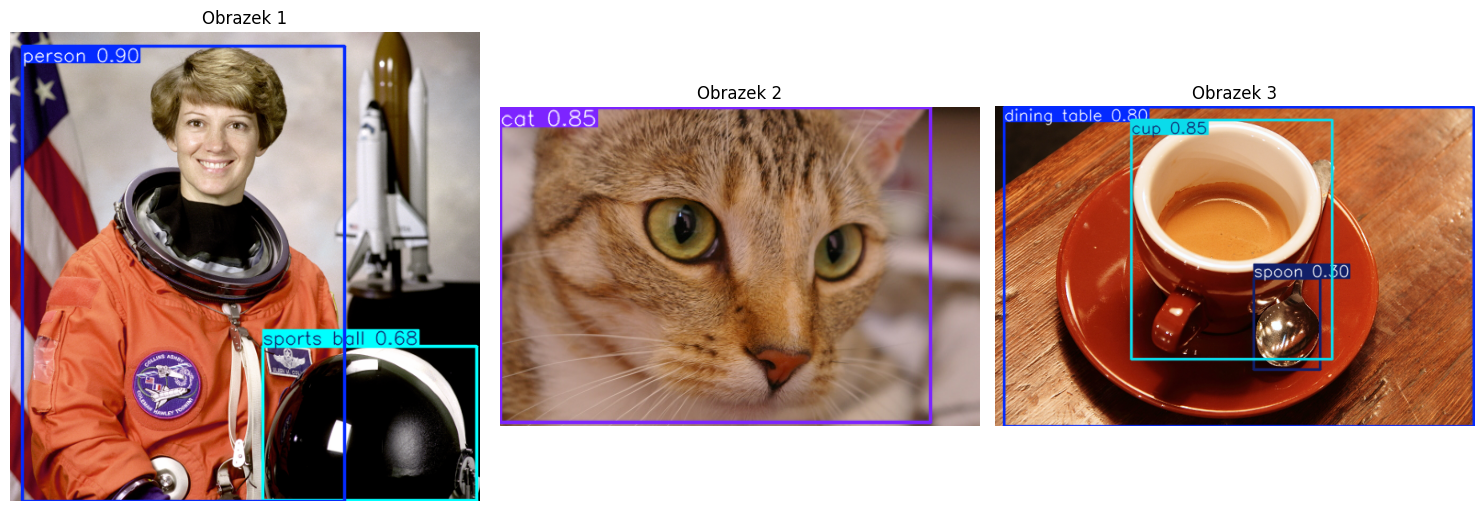

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, r in enumerate(results):
    # Metoda .plot() rysuje ramki na obrazku. Zwraca obraz w formacie BGR.
    # Musimy odwrócić kanały na RGB (z użyciem [..., ::-1]), aby matplotlib wyświetlił dobre kolory.
    img_plotted = r.plot()[..., ::-1] 
    
    axes[i].imshow(img_plotted)
    axes[i].set_title(f"Obrazek {i+1}")
    axes[i].axis("off") 

plt.tight_layout()
plt.show()

In [4]:
# Wybieramy wyniki dla trzeciego zdjęcia (Filiżanka kawy)
res = results[2]
boxes = res.boxes

print("KSZTAŁTY")
# boxes.xyxy zawiera współrzędne [x1, y1, x2, y2]
print(f"Kształt tensora ramek (boxes.xyxy): {boxes.xyxy.shape}") 
# boxes.cls zawiera ID klas
print(f"Kształt tensora klas (boxes.cls): {boxes.cls.shape}")
# boxes.conf zawiera wyniki confidence
print(f"Kształt tensora pewności (boxes.conf): {boxes.conf.shape}\n")

print("SUROWE WARTOŚCI")
print("Klasy:", boxes.cls.tolist())
print("Pewność:", [round(c, 2) for c in boxes.conf.tolist()])

print("\nWykryte obiekty:")
for cls_id in boxes.cls.tolist():
    print(f"- {res.names[int(cls_id)]}")

KSZTAŁTY
Kształt tensora ramek (boxes.xyxy): torch.Size([3, 4])
Kształt tensora klas (boxes.cls): torch.Size([3])
Kształt tensora pewności (boxes.conf): torch.Size([3])

SUROWE WARTOŚCI
Klasy: [41.0, 60.0, 44.0]
Pewność: [0.85, 0.8, 0.3]

Wykryte obiekty:
- cup
- dining table
- spoon


In [5]:
table_data = []

for i in range(len(boxes)):
    x1, y1, x2, y2 = boxes.xyxy[i].tolist()
    
    conf = float(boxes.conf[i])
    cls_id = int(boxes.cls[i])
    cls_name = res.names[cls_id]
    
    width = x2 - x1
    height = y2 - y1
    
    table_data.append([
        i, cls_name, f"{conf:.2f}", 
        f"{x1:.1f}", f"{y1:.1f}", f"{x2:.1f}", f"{y2:.1f}", 
        f"{width:.1f}", f"{height:.1f}"
    ])

columns = ["Box index", "Class name", "Confidence", "x1", "y1", "x2", "y2", "Width", "Height"]
df = pd.DataFrame(table_data, columns=columns)
display(df)

,Box index,Class name,Confidence,x1,y1,x2,y2,Width,Height
0,0,cup,0.85,170.5,17.7,421.0,316.3,250.5,298.6
1,1,dining table,0.80,11.3,1.7,598.2,400.0,587.0,398.3
2,2,spoon,0.30,324.0,215.7,406.7,329.3,82.7,113.5


In [7]:
conf_thresholds = [0.25, 0.50]
threshold_data = []

for c in conf_thresholds:
    res_thresh = model.predict(source=images[2], device=device, conf=c, verbose=False)[0]
    
    num_detections = len(res_thresh.boxes)
    
    threshold_data.append([c, num_detections])

df_thresh = pd.DataFrame(threshold_data, columns=["Confidence threshold", "Number of detections"])
display(df_thresh)

,Confidence threshold,Number of detections
0,0.25,3
1,0.50,2


### Required Discussion: Object Detection

1. **What the YOLO model returns for one image:** 
The YOLO model returns a structured tensor containing multiple predictions. 
For each detected object, it outputs the bounding box coordinates (which can be `x1, y1, x2, y2` or `center_x, center_y, width, height`), the predicted class ID (with the class probabilities), and a confidence score.

2. **What the confidence score means during inference:**
As discussed in Lecture 8 (Section 13), during inference, the final score for a class is computed as `confidence * P(class|object)`. A high confidence score means the model is highly certain that an object exists in that location AND that the predicted bounding box accurately encloses it (high expected IoU with the ground truth).

3. **Why changing the confidence threshold changes the number of detections:**
The model initially predicts many overlapping and uncertain boxes. By raising the confidence threshold (from 0.25 to 0.50), we instruct the model to filter out and discard predictions it is unsure about. Consequently, a higher threshold results in fewer, but generally more reliable, detections.

4. **What object detection predicts:**
Unlike image classification which just predicts a single label for the whole image ("cat"), object detection predicts **both what objects are present and where they are located**. The output is a set of `(box, class, confidence)` tuples.

# Task 2

In [9]:
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

weights = DeepLabV3_ResNet50_Weights.DEFAULT
seg_model = deeplabv3_resnet50(weights=weights).to(device)
seg_model.eval()

preprocess = weights.transforms()
categories = weights.meta["categories"]

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /Users/zoga/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100.0%


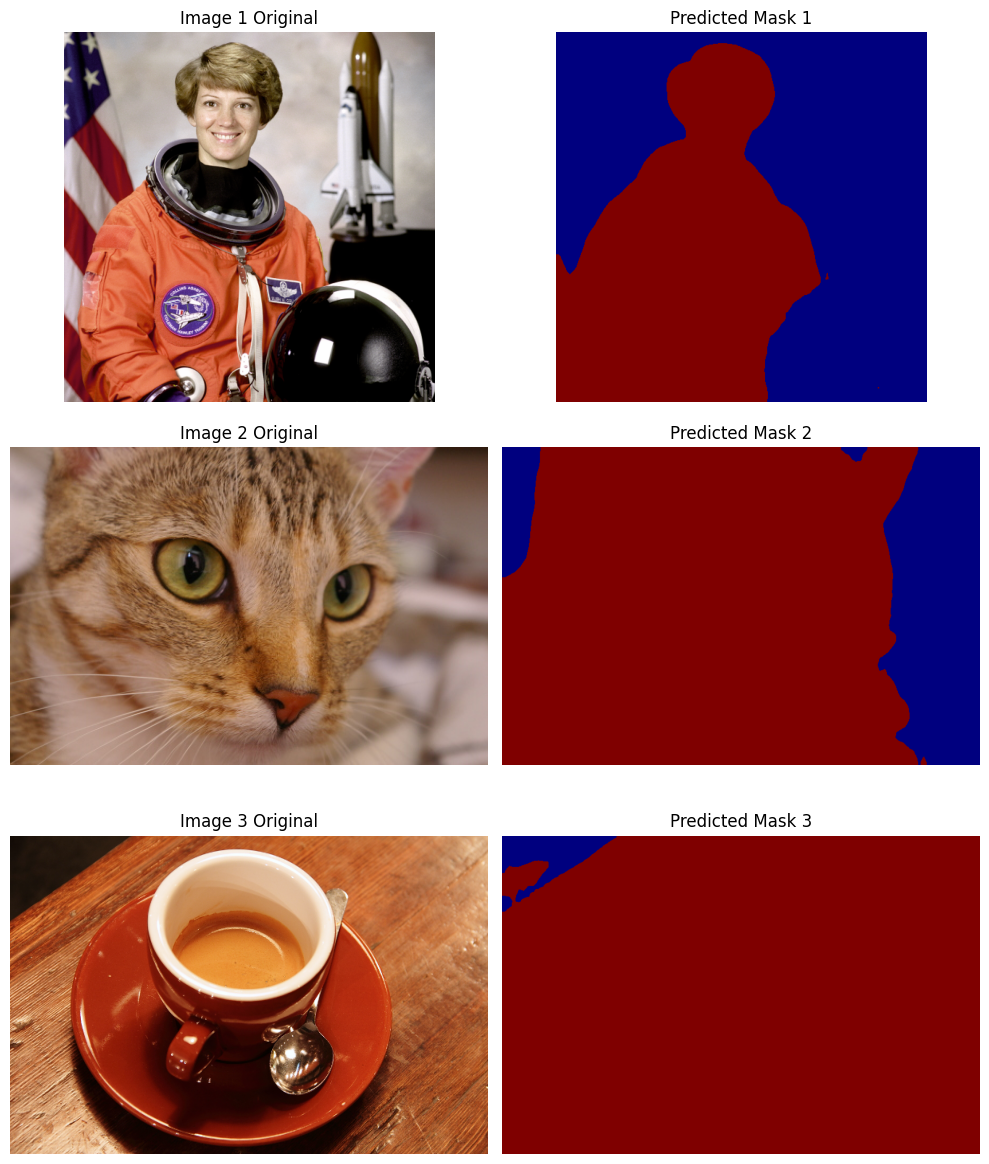

In [11]:
masks = []
raw_outputs = []

with torch.no_grad():
    for img in images:
        input_tensor = preprocess(img)
        
        input_batch = input_tensor.unsqueeze(0).to(device)
        
        output = seg_model(input_batch)['out'][0] 
        raw_outputs.append(output)
        
        mask = output.argmax(0).byte().cpu().numpy()
        masks.append(mask)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for i in range(3):
    # Kolumna 1: Oryginał
    axes[i, 0].imshow(images[i])
    axes[i, 0].set_title(f"Image {i+1} Original")
    axes[i, 0].axis('off')
    
    # Kolumna 2: Maska 
    axes[i, 1].imshow(masks[i], cmap='jet')
    axes[i, 1].set_title(f"Predicted Mask {i+1}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [15]:
idx = 1
img_shape = np.array(images[idx]).shape     # Kształt oryginalnego obrazka (H, W, C)
logits_shape = raw_outputs[idx].shape       # Kształt wyjścia z modelu [K, H, W]
mask_shape = masks[idx].shape               # Kształt ostatecznej maski [H, W]

unique_ids = np.unique(masks[idx])
class_names = [categories[class_id] for class_id in unique_ids]

print(f"Kształt wejściowego obrazka: {img_shape}")
print(f"Kształt wyjścia z modelu (Logits): {logits_shape}")
print(f"Kształt przewidzianej maski: {mask_shape}")
print(f"Unikalne ID klas na masce: {unique_ids.tolist()}")
print(f"Nazwy wykrytych klas: {class_names}\n")

table_data = []

for i in range(3):
    u_ids = np.unique(masks[i]).tolist()
    c_names = [categories[c_id] for c_id in u_ids if c_id != 0] 
    if not c_names:
        c_names = ["Tylko tło"]
        
    table_data.append([
        f"Image {i+1}", 
        str(raw_outputs[i].shape), 
        str(c_names)
    ])

df_seg = pd.DataFrame(table_data, columns=["Image", "Output shape", "Predicted class IDs (Names)"])
display(df_seg)

Kształt wejściowego obrazka: (300, 451, 3)
Kształt wyjścia z modelu (Logits): torch.Size([21, 520, 781])
Kształt przewidzianej maski: (520, 781)
Unikalne ID klas na masce: [0, 8]
Nazwy wykrytych klas: ['__background__', 'cat']



,Image,Output shape,Predicted class IDs (Names)
0,Image 1,"torch.Size([21, 520, 520])",['person']
1,Image 2,"torch.Size([21, 520, 781])",['cat']
2,Image 3,"torch.Size([21, 520, 780])",['diningtable']


### Required Discussion: Semantic Segmentation

1. **What semantic segmentation predicts:**
It predicts a class (like "cat", "person" or "background") for **every single pixel** in the image.

2. **Why the output is spatial:**
Because it is a 2D mask. Every pixel in the original picture needs a predicted pixel in the output.

3. **Why the output shape is usually similar to B × K × H × W:**
* **B** = Batch size (number of images)
* **K** = Number of classes
* **H** = Height of the image
* **W** = Width of the image
The model gives a score for every class (K) at every pixel (H, W).

4. **What K means:**
It is the total number of categories the model knows (for example, 21 different classes).

5. **Why argmax converts logits into class labels:**
For every pixel, the model gives `K` scores (logits). `argmax` simply picks the ID of the class that got the highest score.

6. **How segmentation is different from object detection:**
Detection uses rectangles and counts objects separately (e.g., Cat 1, Cat 2). Segmentation colors exact pixels but blends objects of the same class together (e.g., two cats become one big "cat" blob).

---

### Final Comparison

* **What does object detection predict?** Objects, their bounding boxes, and confidence.
* **What does semantic segmentation predict?** A class label for every pixel.
* **Which task uses bounding boxes?** Object Detection.
* **Which task uses pixel-wise labels?** Semantic Segmentation.
* **Which task was easier to visualize and why?** Object Detection. Drawing a few rectangles on an image is much easier than coloring and blending thousands of pixels to make a mask.